In [1]:
import slicersim

/Users/griffin/PycharmProjects/twins_embedding/twins_embedding.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
import slicersim

config = slicersim.iotools.get_config(scene='twins_embedding.toml')
sim = slicersim.Simulation.from_config(config)

In [3]:
sim

--------------------- Scene ----------------------
{'target': {'name': 'SN Ia',
            'source': 'twins-embedding',
            'redshift': 1.5,
            'phase': 0,
            'position': [1, 0.5],
            'magnitude': 0.1,
            'color': 0.1,
            'coordinates': [0.0, 1.0, 2.0]},
 'background': {'model': 'Aldering01.BB5800', 'scale': 2.0, 'name': 'zodi'},
 'host': None}
------------------ Spectrograph ------------------
Spectrograph 'NACRE (baseline)':
  Spectral range: 4_000-17_000 Å, 456 px
  Spectral dispersion: 'dispersion_offner.ecsv' ×1.3 (R0~141)
  Spectral PSF: chromatic σ=0.90 px at 1 µm, x-disp. σ=0.30 px
  Resolving power (2-px + σ): R~127 (λ-average), min=95 at 12_802 Å
  MLA: 15×16 spx of 40 mas
  Spatial PSF: chromatic σ=30 mas at 1 µm, guiding σ=10 mas
  Total throughput: 'throughput_baseline.ecsv' (~58%)
  Mirror: 32 m² at 288 K, emissivity: 0.10
-------------------- Detector --------------------
Detector 'H4RG17':
  10 µm px, dark: 0.010 e-/

# Obtain a spectrum

In [4]:
lbda, flux, variance = sim.get_spectrum(incl_error=True)

/Users/griffin/PycharmProjects/slicersim/slicersim/spectrograph.py:669: RuntimeWarning: divide by zero encountered in divide
  variance = 1 / (psf[:, aper]**2 / varcube[:, aper]).sum(axis=-1)


In [5]:
sim.scene.update(target__redshift=1.2)
lbda, flux_1, variance_1 = sim.get_spectrum(incl_error=True)

sim.scene.update(target__redshift=0.7)
lbda, flux_2, variance_2 = sim.get_spectrum(incl_error=True)

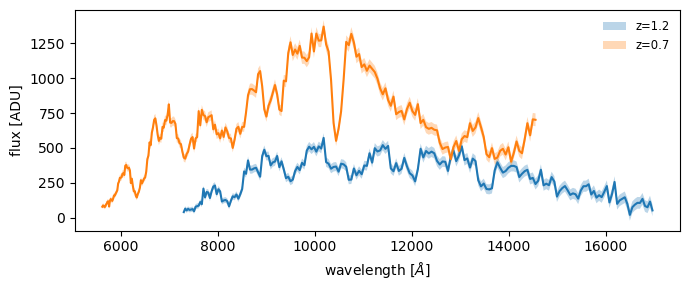

In [6]:
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=[7,3])

ax.plot(lbda, flux_1)
ax.fill_between(lbda, 
                flux_1-np.sqrt(variance_1),
                flux_1+np.sqrt(variance_1), alpha=0.3,
               label="z=1.2")

ax.plot(lbda, flux_2)
ax.fill_between(lbda, 
                flux_2-np.sqrt(variance_2),
                flux_2+np.sqrt(variance_2), alpha=0.3,
               label="z=0.7")
ax.legend(frameon=False, fontsize="small")
ax.set(xlabel=r"wavelength [$\AA$]", ylabel="flux [ADU]")
fig.tight_layout()
# fig.savefig("/Users/rigault/libraries/from_perl/slicersim/docs/gallery/spectra_examples.png", dpi=100)

# Get the variance origin

In [7]:
sim.estimate_variance_contribution([8000, 12000], frame="obs")

{'snr': 22.20955395321379,
 'exptime': 724.48,
 'inttime': 679.2,
 'obstime': 724.48,
 'signal': 925.4040619129129,
 'variance': 1736.1335509596802,
 'frac_dark': 0.18437340718868017,
 'frac_ron': 0.09562094151719358,
 'frac_background': 0.054387028371347054,
 'frac_target': 0.7370465042603517,
 'frac_thermal': 3.628606046359523e-08}

In [8]:
sim.update(detector__ron=200)

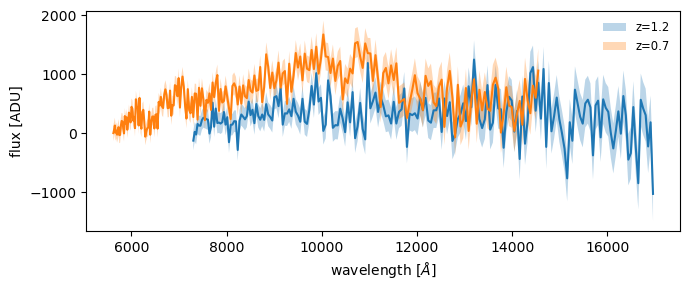

In [9]:
sim.update(target__redshift=1.2)
lbda, flux_1, variance_1 = sim.get_spectrum(incl_error=True)

sim.update(target__redshift=0.7)
lbda, flux_2, variance_2 = sim.get_spectrum(incl_error=True)


import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=[7,3])

ax.plot(lbda, flux_1)
ax.fill_between(lbda, 
                flux_1-np.sqrt(variance_1),
                flux_1+np.sqrt(variance_1), alpha=0.3,
               label="z=1.2")

ax.plot(lbda, flux_2)
ax.fill_between(lbda, 
                flux_2-np.sqrt(variance_2),
                flux_2+np.sqrt(variance_2), alpha=0.3,
               label="z=0.7")
ax.legend(frameon=False, fontsize="small")
ax.set(xlabel=r"wavelength [$\AA$]", ylabel="flux [ADU]")
fig.tight_layout()
#fig.savefig("/Users/rigault/libraries/from_perl/slicersim/docs/gallery/spectra_examples.png", dpi=100)

In [10]:
sim.get_band_snr([4000, 6000], frame="rest")

4.077089079623116

In [11]:
sim.get_band_flux([4000, 6000], frame="rest")

(782.2839388093504, 36815.307034189915)

# Recover the input parameters

In [7]:
from twins_embedding import TwinsEmbeddingModel
from iminuit import Minuit, cost
from astropy.cosmology import WMAP9 as cosmo

In [8]:
# define the Twins Embedding model
model = TwinsEmbeddingModel()

def trained_model(wave, dm, av, xi1, xi2, xi3, phase):
    flux, flux_error = model.evaluate(magnitude=dm, color=av, 
                                      coordinates=[xi1, xi2, xi3], phase=phase)
    flux_interp = np.interp(wave, model.wave, flux)
    return flux_interp

Text(0, 0.5, '$F_\\lambda$ at $z=0.05$ ($10^{-15}$ erg/s/cm²/Å)')

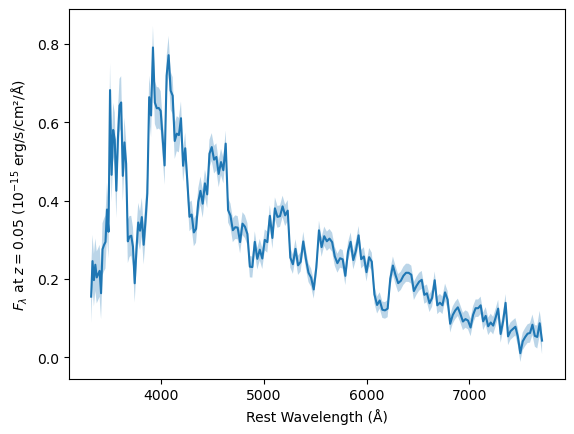

In [9]:
# choose your input spectrum and known redshift
wl_in = lbda
flux_in = flux_1
var_in = variance_1
redshift = 1.2

# remove NaNs
finite = np.isfinite(flux_in)
wl_in = wl_in[finite]
flux_in = flux_in[finite]
var_in = var_in[finite]

# calibrate the spectrum and scale to z=0.05, shift the wavelength to the rest frame
sensfunc = np.interp(wl_in, *sim.get_effective_transmission()) * 1e-15
background = sim.scene.background.get_spectrum(wl_in)[1] / 1e-15
dist_ratio = cosmo.luminosity_distance(redshift) / cosmo.luminosity_distance(0.05)
cosmo_k_corr = (1. + redshift) / 1.05

xfit = wl_in / (1. + redshift)
yfit = flux_in * dist_ratio ** 2. * cosmo_k_corr / sensfunc - background
wfit = np.sqrt(var_in) * dist_ratio ** 2. * cosmo_k_corr / sensfunc

plt.plot(xfit, yfit)
plt.fill_between(xfit, yfit - wfit, yfit + wfit, alpha=0.3)
plt.xlabel('Rest Wavelength (Å)')
plt.ylabel('$F_\lambda$ at $z=0.05$ ($10^{-15}$ erg/s/cm²/Å)')

In [10]:
# set up and run the fit
m = Minuit(cost.LeastSquares(xfit, yfit, wfit, trained_model),
           
           # initial guesses
           dm=0.,
           av=0.,
           xi1=0.,
           xi2=0.,
           xi3=0.,
           phase=0.,
           
           # fix parameters?
           fix_dm=False,
           fix_av=False,
           fix_xi1=False,
           fix_xi2=False,
           fix_xi3=False,
           fix_phase=True,
           
           # initial step sizes
           error_dm=0.05,
           error_av=0.03,
           error_xi1=0.5,
           error_xi2=0.2,
           error_xi3=0.5,

           # parameter limits
           limit_dm=(-10., 10.),
           limit_av=(-0.4, 0.7),
           limit_xi1=(-10., 10.),
           limit_xi2=(-10., 10.),
           limit_xi3=(-10., 10.),
          )

m.migrad()

┌──────────────────────────────────┬──────────────────────────────────────┐
│ FCN = 193.5                      │        Nfcn = 165 (165 total)        │
│ EDM = 1.54e-06 (Goal: 0.0002)    │                                      │
├───────────────┬──────────────────┼──────────────────────────────────────┤
│ Valid Minimum │ Valid Parameters │        No Parameters at limit        │
├───────────────┴──────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│   Hesse ok    │  Has Covariance  │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ dm    │   0.06    │   0.04    │            │            │   -10   │   10    │       │
│ 1 │ av    │   0.102   │   0.032   │            │            │  -0.4   │   0.7   │       │
│ 2 │ xi1   │   0.05    │   0.25    │            │            │   -10   │   10    │       │
│ 3 │ xi2   │   0.86    │   0.33    │            │            │   -10   │   10    │       │
│ 4 │ xi3   │   2.38    │   0.19    │            │            │   -10   │   10    │       │
│ 5 │ phase │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘

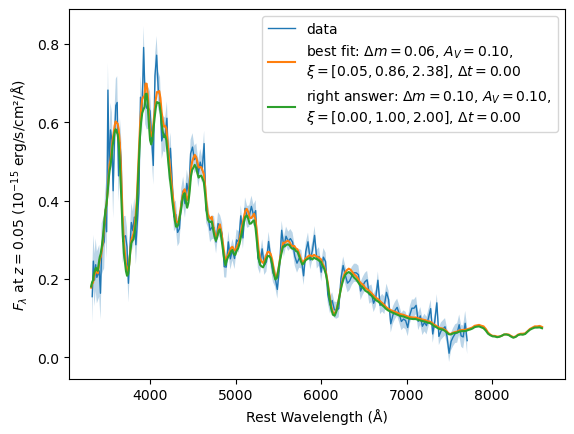

In [11]:
# plot the results
param_spec = '''$\\Delta m = {magnitude:.2f}$, $A_V = {color:.2f}$,
$\\xi = [{coordinates[0]:.2f}, {coordinates[1]:.2f}, {coordinates[2]:.2f}]$, $\\Delta t = {phase:.2f}$'''

plt.plot(xfit, yfit, label='data', lw=1)
plt.fill_between(xfit, yfit - wfit, yfit + wfit, alpha=0.3)

best_fit = trained_model(model.wave, *m.args)
plt.plot(model.wave, best_fit, label='best fit: ' + param_spec.format(magnitude=m.args[0], color=m.args[1],
                                                                      coordinates=m.args[2:5], phase=m.args[5]))

right_answer = trained_model(model.wave,
                             sim.scene.target.meta['magnitude'],
                             sim.scene.target.meta['color'],
                             *sim.scene.target.meta['coordinates'],
                             sim.scene.target.meta['phase']
                            )
plt.plot(model.wave, right_answer, label='right answer: ' + param_spec.format(**sim.scene.target.meta))

plt.xlabel('Rest Wavelength (Å)')
plt.ylabel('$F_\lambda$ at $z=0.05$ ($10^{-15}$ erg/s/cm²/Å)')
plt.legend()